# Assignment 1: Neural Networks

**Steve Lambert**  
**BA 64061: Advanced Machine Learning**

For this assignment, I used the IMDB movie review example from Chapter 4. I started with the original model and changed the number of layers, number of units, loss function, activation function, and regularization.

## Load the packages and data

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Keep the 10,000 most common words in the reviews
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(
    num_words=10000
)

print("Training reviews:", len(train_data))
print("Test reviews:", len(test_data))

Training reviews: 25000
Test reviews: 25000


The reviews are stored as lists of word numbers. I converted each review into a vector of zeros and ones. A 1 means that the word appeared in the review.

In [3]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results


x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

# Use 10,000 reviews for validation, as shown in the chapter
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print("Training shape:", partial_x_train.shape)
print("Validation shape:", x_val.shape)

Training shape: (15000, 10000)
Validation shape: (10000, 10000)


## Create and test the models

The starting model has two hidden layers with 16 units in each layer. It uses ReLU for the hidden layers, sigmoid for the output, RMSprop as the optimizer, and binary cross-entropy as the loss function.

I trained each version for 10 epochs using the same training and validation data. I recorded the validation accuracy from the epoch with the lowest validation loss.

In [4]:
def make_model(units, activation="relu", loss="binary_crossentropy",
               dropout=0.0, l2_value=0.0):
    model = keras.Sequential()
    model.add(keras.Input(shape=(10000,)))

    for number_of_units in units:
        model.add(
            layers.Dense(
                number_of_units,
                activation=activation,
                kernel_regularizer=regularizers.l2(l2_value) if l2_value > 0 else None,
            )
        )
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="rmsprop", loss=loss, metrics=["accuracy"])
    return model


def test_model(name, units, activation="relu", loss="binary_crossentropy",
               dropout=0.0, l2_value=0.0):
    keras.backend.clear_session()
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)

    model = make_model(units, activation, loss, dropout, l2_value)
    history = model.fit(
        partial_x_train,
        partial_y_train,
        epochs=10,
        batch_size=512,
        validation_data=(x_val, y_val),
        verbose=0,
    )

    history_df = pd.DataFrame(history.history)
    best_row = history_df["val_loss"].idxmin()

    result = {
        "Model": name,
        "Layers": len(units),
        "Units": " x ".join(str(x) for x in units),
        "Activation": activation,
        "Loss": loss,
        "Dropout": dropout,
        "L2": l2_value,
        "Best Epoch": int(best_row + 1),
        "Validation Accuracy": history_df.loc[best_row, "val_accuracy"],
        "Validation Loss": history_df.loc[best_row, "val_loss"],
    }

    return model, history_df, result

In [5]:
experiments = [
    ("Baseline", [16, 16], "relu", "binary_crossentropy", 0.0, 0.0),
    ("One hidden layer", [16], "relu", "binary_crossentropy", 0.0, 0.0),
    ("Three hidden layers", [16, 16, 16], "relu", "binary_crossentropy", 0.0, 0.0),
    ("32 units", [32, 32], "relu", "binary_crossentropy", 0.0, 0.0),
    ("64 units", [64, 64], "relu", "binary_crossentropy", 0.0, 0.0),
    ("MSE loss", [16, 16], "relu", "mse", 0.0, 0.0),
    ("Tanh activation", [16, 16], "tanh", "binary_crossentropy", 0.0, 0.0),
    ("Dropout", [16, 16], "relu", "binary_crossentropy", 0.5, 0.0),
    ("L2 regularization", [16, 16], "relu", "binary_crossentropy", 0.0, 0.001),
]

all_results = []
histories = {}

for experiment in experiments:
    name, units, activation, loss, dropout, l2_value = experiment
    print("Running:", name)
    model, history_df, result = test_model(
        name, units, activation, loss, dropout, l2_value
    )
    histories[name] = history_df
    all_results.append(result)

results = pd.DataFrame(all_results).sort_values(
    "Validation Accuracy", ascending=False
).reset_index(drop=True)

results

Running: Baseline
Running: One hidden layer
Running: Three hidden layers
Running: 32 units
Running: 64 units
Running: MSE loss
Running: Tanh activation
Running: Dropout
Running: L2 regularization


Model,Layers,Units,Activation,Loss,Dropout,L2,Best Epoch,Validation Accuracy,Validation Loss
64 units,2,64 x 64,relu,binary_crossentropy,0.0,0.000,3,0.8903,0.275119
Three hidden layers,3,16 x 16 x 16,relu,binary_crossentropy,0.0,0.000,4,0.8888,0.276743
Dropout,2,16 x 16,relu,binary_crossentropy,0.5,0.000,6,0.8886,0.274460
Baseline,2,16 x 16,relu,binary_crossentropy,0.0,0.000,4,0.8877,0.276728
L2 regularization,2,16 x 16,relu,binary_crossentropy,0.0,0.001,4,0.8875,0.330792
One hidden layer,1,16,relu,binary_crossentropy,0.0,0.000,6,0.8874,0.277155
Tanh activation,2,16 x 16,tanh,binary_crossentropy,0.0,0.000,4,0.8873,0.274950
32 units,2,32 x 32,relu,binary_crossentropy,0.0,0.000,4,0.8860,0.276882
MSE loss,2,16 x 16,relu,mse,0.0,0.000,6,0.8843,0.083674


## Results

In [6]:
results_display = results.copy()
results_display["Validation Accuracy"] = results_display["Validation Accuracy"].map(
    lambda x: f"{x:.2%}"
)
results_display["Validation Loss"] = results_display["Validation Loss"].map(
    lambda x: f"{x:.4f}"
)
results_display

Model,Layers,Units,Activation,Loss,Dropout,L2,Best Epoch,Validation Accuracy,Validation Loss
64 units,2,64 x 64,relu,binary_crossentropy,0.0,0.000,3,89.03%,0.2751
Three hidden layers,3,16 x 16 x 16,relu,binary_crossentropy,0.0,0.000,4,88.88%,0.2767
Dropout,2,16 x 16,relu,binary_crossentropy,0.5,0.000,6,88.86%,0.2745
Baseline,2,16 x 16,relu,binary_crossentropy,0.0,0.000,4,88.77%,0.2767
L2 regularization,2,16 x 16,relu,binary_crossentropy,0.0,0.001,4,88.75%,0.3308
One hidden layer,1,16,relu,binary_crossentropy,0.0,0.000,6,88.74%,0.2772
Tanh activation,2,16 x 16,tanh,binary_crossentropy,0.0,0.000,4,88.73%,0.2750
32 units,2,32 x 32,relu,binary_crossentropy,0.0,0.000,4,88.60%,0.2769
MSE loss,2,16 x 16,relu,mse,0.0,0.000,6,88.43%,0.0837


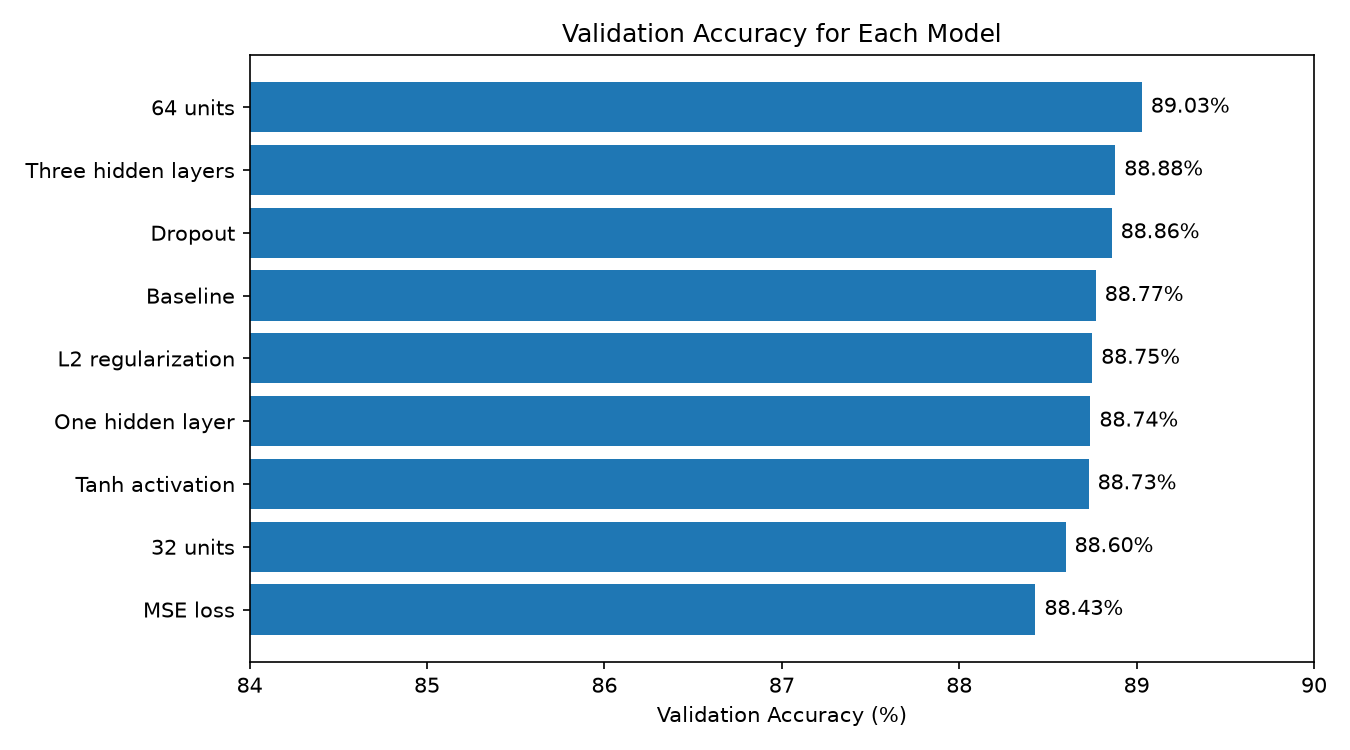

In [7]:
plot_data = results.sort_values("Validation Accuracy")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["Model"], plot_data["Validation Accuracy"] * 100)
plt.xlabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Each Model")
plt.xlim(84, 90)

for i, value in enumerate(plot_data["Validation Accuracy"] * 100):
    plt.text(value + 0.05, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.savefig("assignment1_model_comparison.png", dpi=150)
plt.show()

### Baseline training history

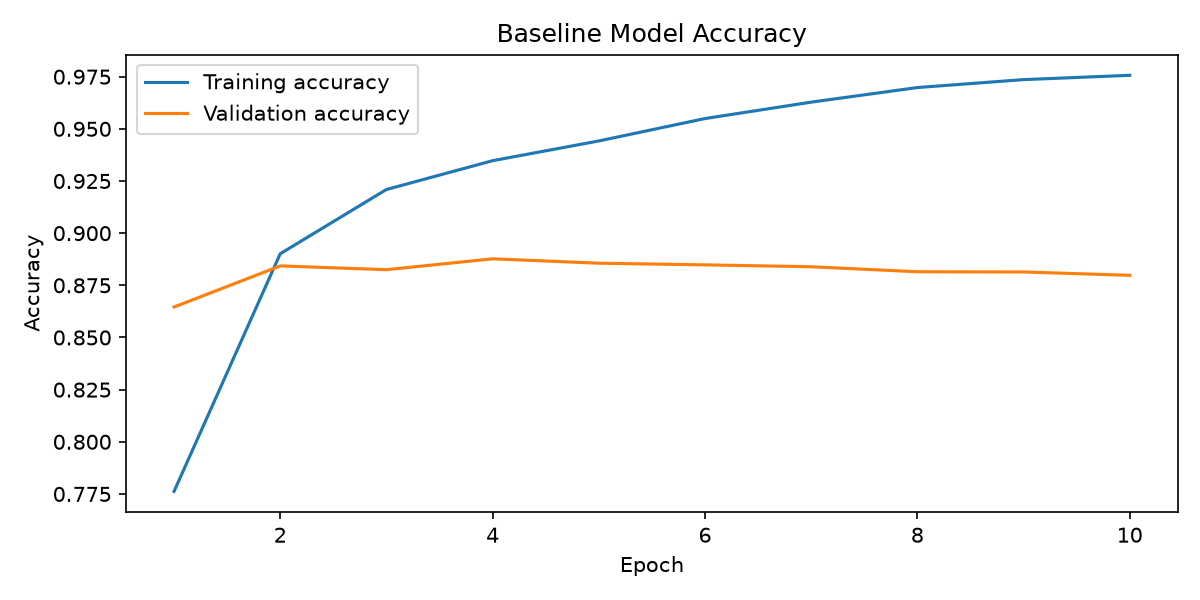

In [8]:
baseline_history = histories["Baseline"]
epochs = range(1, len(baseline_history) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, baseline_history["accuracy"], label="Training accuracy")
plt.plot(epochs, baseline_history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("assignment1_baseline_accuracy.png", dpi=150)
plt.show()

## Final model

I selected the model with the highest validation accuracy. I then trained that version again using all 25,000 training reviews. The number of epochs came from its best validation result. The test set was only used for this final evaluation.

In [9]:
best_name = results.loc[0, "Model"]
best_epoch = int(results.loc[0, "Best Epoch"])
best_experiment = next(item for item in experiments if item[0] == best_name)

name, units, activation, loss, dropout, l2_value = best_experiment
final_model = make_model(units, activation, loss, dropout, l2_value)

final_model.fit(
    x_train,
    y_train,
    epochs=best_epoch,
    batch_size=512,
    verbose=0,
)

test_loss, test_accuracy = final_model.evaluate(x_test, y_test, verbose=0)

print("Selected model:", best_name)
print("Epochs used:", best_epoch)
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Test loss: {test_loss:.4f}")

Selected model: 64 units
Epochs used: 3
Test accuracy: 88.66%
Test loss: 0.2813


## Conclusion

The baseline model reached 88.77% validation accuracy. The best result came from the 64 units model, which reached 89.03%. The number of layers did not make a large difference, and adding more layers did not automatically improve the result. The MSE model performed worse than the model using binary cross-entropy, which makes sense because this is a binary classification problem. Tanh was close to ReLU but did not improve the result. Dropout slightly improved on the baseline, while L2 regularization was about the same. The training graph also shows that training accuracy continued increasing after validation accuracy leveled off, which is a sign of overfitting. The final model achieved 88.66% accuracy on the test data. Overall, changing the number of units helped a little, but the results showed that a larger or deeper model is not always better.